In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_theme(style="whitegrid")


# ---------------------------------------------------------
# PATHS — ancrés sur la racine du projet
# ---------------------------------------------------------

def find_project_root(marker: str = "pyproject.toml") -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant `marker`."""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Racine du projet introuvable (marqueur: {marker})"
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PRICE_FILE = PROCESSED_DIR / "adjusted_close_prices.csv"
RETURN_FILE = PROCESSED_DIR / "daily_returns.csv"

FEATURE_FILE_CSV = PROCESSED_DIR / "classical_macd_features.csv"
FEATURE_FILE_PARQUET = PROCESSED_DIR / "classical_macd_features.parquet"

assert PRICE_FILE.exists(), f"Introuvable : {PRICE_FILE}"
assert RETURN_FILE.exists(), f"Introuvable : {RETURN_FILE}"

print(f"Project root  : {PROJECT_ROOT}")
print(f"Processed dir : {PROCESSED_DIR}")

Project root  : C:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum
Processed dir : C:\Users\SETUP GAME\OneDrive\Desktop\Sun_project\Time_series_momentum\data\processed


In [3]:
# ---------------------------------------------------------
# PARAMETERS MACD
# ---------------------------------------------------------

MACD_PAIRS = [
    (8, 24),
    (16, 48),
    (32, 96),
]

PRICE_STD_WINDOW = 63
SIGNAL_STD_WINDOW = 252

VOLATILITY_HALFLIFE = 60
ANNUALIZATION_FACTOR = 252

In [4]:
prices = pd.read_csv(
    PRICE_FILE,
    index_col=0,
    parse_dates=True,
)

daily_returns = pd.read_csv(
    RETURN_FILE,
    index_col=0,
    parse_dates=True,
)


prices.index.name = "date"
daily_returns.index.name = "date"

prices.columns.name = "ticker"
daily_returns.columns.name = "ticker"


# Conserver uniquement les colonnes communes
common_tickers = prices.columns.intersection(
    daily_returns.columns
)

prices = prices[common_tickers].copy()
daily_returns = daily_returns[common_tickers].copy()


# Aligner les calendriers
prices, daily_returns = prices.align(
    daily_returns,
    join="inner",
    axis=0,
)


print("Prices shape       :", prices.shape)
print("Daily returns shape:", daily_returns.shape)
print("Number of tickers  :", len(common_tickers))

display(prices.head())
display(daily_returns.head())

Prices shape       : (11765, 20)
Daily returns shape: (11765, 20)
Number of tickers  : 20


ticker,AAPL,AMZN,BA,BAC,CAT,CVX,GE,GOOGL,GS,JNJ,JPM,KO,MCD,MSFT,NKE,PFE,PG,UNH,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,1.887720,0.541403,2.355475,1.228714,1.407485,NaN,NaN,0.521387,NaN,0.186990,0.444125,NaN,NaN,0.160055,0.618565,NaN,0.024395,0.470878
1980-01-03,NaN,NaN,1.911494,0.536390,2.333358,1.231547,1.425529,NaN,NaN,0.522236,NaN,0.191838,0.442827,NaN,NaN,0.160055,0.610234,NaN,0.024122,0.458860
1980-01-04,NaN,NaN,2.096939,0.536390,2.366533,1.225884,1.472446,NaN,NaN,0.529878,NaN,0.193916,0.449320,NaN,NaN,0.165924,0.613358,NaN,0.024668,0.463230
1980-01-07,NaN,NaN,2.173018,0.541403,2.355475,1.225884,1.522970,NaN,NaN,0.529029,NaN,0.193223,0.445424,NaN,NaN,0.165924,0.610234,NaN,0.024577,0.461045
1980-01-08,NaN,NaN,2.206302,0.536390,2.377592,1.237209,1.577105,NaN,NaN,0.550258,NaN,0.194608,0.451917,NaN,NaN,0.173926,0.612317,NaN,0.025032,0.464323


ticker,AAPL,AMZN,BA,BAC,CAT,CVX,GE,GOOGL,GS,JNJ,JPM,KO,MCD,MSFT,NKE,PFE,PG,UNH,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,0.012594,-0.009259,-0.009390,0.002305,0.012820,NaN,NaN,0.001629,NaN,0.025927,-0.002924,NaN,NaN,0.000000,-0.013468,NaN,-0.011187,-0.025523
1980-01-04,NaN,NaN,0.097015,0.000000,0.014218,-0.004598,0.032912,NaN,NaN,0.014634,NaN,0.010831,0.014663,NaN,NaN,0.036666,0.005119,NaN,0.022629,0.009524
1980-01-07,NaN,NaN,0.036281,0.009346,-0.004673,0.000000,0.034313,NaN,NaN,-0.001603,NaN,-0.003572,-0.008670,NaN,NaN,0.000000,-0.005093,NaN,-0.003695,-0.004717
1980-01-08,NaN,NaN,0.015317,-0.009259,0.009389,0.009238,0.035545,NaN,NaN,0.040129,NaN,0.007168,0.014577,NaN,NaN,0.048232,0.003413,NaN,0.018523,0.007109


In [5]:
assert not prices.empty, "The price dataset is empty."
assert not daily_returns.empty, "The return dataset is empty."

assert prices.index.is_monotonic_increasing
assert daily_returns.index.is_monotonic_increasing

assert not prices.index.duplicated().any()
assert not daily_returns.index.duplicated().any()

assert prices.index.equals(daily_returns.index)
assert prices.columns.equals(daily_returns.columns)

assert (prices.dropna() > 0).all().all()

print("Input datasets successfully validated.")

Input datasets successfully validated.


calcule de la fonction mathematique mt​(S)=(1−S1​)mt−1​(S)+S1​Pt qui est la base de notre Expo weighted moving average qui sera la base du macd calcule 

In [6]:
def compute_ewma(
    prices: pd.DataFrame,
    time_scale: int,
) -> pd.DataFrame:
    """
    Compute the exponentially weighted moving average using
    alpha = 1 / time_scale.

    Only current and historical prices are used.
    """

    if time_scale <= 0:
        raise ValueError("time_scale must be strictly positive.")

    return prices.ewm(
        alpha=1 / time_scale,
        adjust=False,
        min_periods=time_scale,
        ignore_na=True,
    ).mean()

calcule de macd avec la formule MACDt​(S,L)=EWMAt​(S)−EWMAt​(L) attention c'est un macd brute pas normalise

In [7]:
def compute_macd(
    prices: pd.DataFrame,
    short_scale: int,
    long_scale: int,
) -> pd.DataFrame:
    """
    Compute the raw MACD for every asset.
    """

    if short_scale >= long_scale:
        raise ValueError(
            "short_scale must be smaller than long_scale."
        )

    short_ewma = compute_ewma(
        prices=prices,
        time_scale=short_scale,
    )

    long_ewma = compute_ewma(
        prices=prices,
        time_scale=long_scale,
    )

    return short_ewma - long_ewma

notre premiere formule de normalisation Qt​(S,L)=Std(Pt−62​,…,Pt​)MACDt​(S,L)​

In [8]:
def normalize_macd_by_price_std(
    macd: pd.DataFrame,
    prices: pd.DataFrame,
    window: int = 63,
) -> pd.DataFrame:
    """
    Normalize the MACD using the rolling standard deviation
    of prices over the previous `window` observations.
    """

    rolling_price_std = prices.rolling(
        window=window,
        min_periods=window,
    ).std(ddof=1)

    rolling_price_std = rolling_price_std.replace(
        0,
        np.nan,
    )

    return macd / rolling_price_std

calcule du premier critere majeur du paper research trend estimator score :!
Yt​(S,L)=Std(Qt−251​,…,Qt​)Qt​(S,L)​

In [9]:
def standardize_macd_signal(
    normalized_macd: pd.DataFrame,
    window: int = 252,
) -> pd.DataFrame:
    """
    Standardize normalized MACD using its own trailing
    historical standard deviation.
    """

    rolling_signal_std = normalized_macd.rolling(
        window=window,
        min_periods=window,
    ).std(ddof=1)

    rolling_signal_std = rolling_signal_std.replace(
        0,
        np.nan,
    )

    return normalized_macd / rolling_signal_std

application des fonction definie pour calcule les variable necessaire de macd 

In [10]:
macd_features = {}

for short_scale, long_scale in MACD_PAIRS:

    feature_suffix = f"{short_scale}_{long_scale}"

    # 1. Exponential moving averages
    ewma_short = compute_ewma(
        prices,
        time_scale=short_scale,
    )

    ewma_long = compute_ewma(
        prices,
        time_scale=long_scale,
    )

    # 2. Raw MACD
    macd_raw = ewma_short - ewma_long

    # 3. MACD normalized by price variability
    macd_normalized = normalize_macd_by_price_std(
        macd=macd_raw,
        prices=prices,
        window=PRICE_STD_WINDOW,
    )

    # 4. Final standardized trend score
    trend_score = standardize_macd_signal(
        normalized_macd=macd_normalized,
        window=SIGNAL_STD_WINDOW,
    )

    macd_features[f"ewma_{short_scale}"] = ewma_short
    macd_features[f"ewma_{long_scale}"] = ewma_long

    macd_features[f"macd_{feature_suffix}"] = macd_raw

    macd_features[
        f"normalized_macd_{feature_suffix}"
    ] = macd_normalized

    macd_features[
        f"trend_score_{feature_suffix}"
    ] = trend_score


print("Created variables:")

for feature_name in macd_features:
    print("-", feature_name)

Created variables:
- ewma_8
- ewma_24
- macd_8_24
- normalized_macd_8_24
- trend_score_8_24
- ewma_16
- ewma_48
- macd_16_48
- normalized_macd_16_48
- trend_score_16_48
- ewma_32
- ewma_96
- macd_32_96
- normalized_macd_32_96
- trend_score_32_96


calcule de la volatilite necessaire au backtest qui est annualise : σt​=EWMAStd60​(rt​)252
​

In [11]:
def compute_annualized_ewma_volatility(
    returns: pd.DataFrame,
    halflife: int = 60,
    annualization_factor: int = 252,
) -> pd.DataFrame:
    """
    Compute trailing exponentially weighted annualized volatility.
    """

    volatility = returns.ewm(
        halflife=halflife,
        adjust=False,
        min_periods=halflife,
        ignore_na=True,
    ).std(bias=False)

    return volatility * np.sqrt(annualization_factor)


annualized_volatility_60 = (
    compute_annualized_ewma_volatility(
        returns=daily_returns,
        halflife=VOLATILITY_HALFLIFE,
        annualization_factor=ANNUALIZATION_FACTOR,
    )
)

display(annualized_volatility_60.tail())

ticker,AAPL,AMZN,BA,BAC,CAT,CVX,GE,GOOGL,GS,JNJ,JPM,KO,MCD,MSFT,NKE,PFE,PG,UNH,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,
2026-08-31,0.276483,0.387232,0.349398,0.209495,0.414965,0.247966,0.341801,0.343798,0.340773,0.214431,0.215482,0.205945,0.203243,0.377973,0.362491,0.220868,0.201595,0.329711,0.284799,0.268450
2026-09-01,0.278096,0.386457,0.347786,0.208291,0.414534,0.249367,0.340715,0.342575,0.340361,0.215484,0.214367,0.205318,0.202086,0.376603,0.360947,0.219615,0.200840,0.329050,0.283757,0.269238
2026-09-02,0.276517,0.384232,0.346859,0.207587,0.413078,0.247943,0.338872,0.340742,0.338404,0.215373,0.213168,0.204151,0.200922,0.374849,0.358982,0.219824,0.200363,0.327395,0.282150,0.267782
2026-09-03,0.275296,0.382814,0.345138,0.206605,0.410997,0.246617,0.337497,0.339777,0.340917,0.214766,0.213480,0.203164,0.199894,0.375073,0.357941,0.219078,0.199393,0.325528,0.283145,0.267226
2026-09-04,0.277454,0.380633,0.343450,0.205448,0.409583,0.246485,0.336011,0.338417,0.338955,0.214770,0.213058,0.202661,0.200216,0.374878,0.356114,0.219115,0.198328,0.324158,0.282175,0.267522


In [12]:
def wide_to_long(
    dataframe: pd.DataFrame,
    value_name: str,
) -> pd.DataFrame:
    """
    Convert a date × ticker matrix into a long panel.

    Note (pandas >= 2.1 / 3.0) : la nouvelle implementation de
    DataFrame.stack() n'accepte plus `dropna` et conserve deja
    toutes les paires (date, ticker), y compris les valeurs NaN.
    Le panel reste donc equilibre, comme avec l'ancien
    `.stack(dropna=False)`.
    """

    return (
        dataframe
        .rename_axis(
            index="date",
            columns="ticker",
        )
        .stack()
        .rename(value_name)
        .reset_index()
    )

Assemblement de la dataset avec tous les variables et critere necessaire !!

In [13]:
feature_dataset = wide_to_long(
    prices,
    value_name="close",
)

return_long = wide_to_long(
    daily_returns,
    value_name="daily_return",
)

volatility_long = wide_to_long(
    annualized_volatility_60,
    value_name="volatility_60",
)


feature_dataset = feature_dataset.merge(
    return_long,
    on=["date", "ticker"],
    how="left",
)

feature_dataset = feature_dataset.merge(
    volatility_long,
    on=["date", "ticker"],
    how="left",
)


# Ajouter toutes les variables MACD
for feature_name, feature_matrix in macd_features.items():

    feature_long = wide_to_long(
        feature_matrix,
        value_name=feature_name,
    )

    feature_dataset = feature_dataset.merge(
        feature_long,
        on=["date", "ticker"],
        how="left",
    )


feature_dataset = feature_dataset.sort_values(
    ["date", "ticker"]
).reset_index(drop=True)


print("Feature dataset shape:", feature_dataset.shape)

display(feature_dataset.head())
display(feature_dataset.tail())

Feature dataset shape: (235300, 20)


,date,ticker,close,daily_return,volatility_60,ewma_8,ewma_24,macd_8_24,normalized_macd_8_24,trend_score_8_24,ewma_16,ewma_48,macd_16_48,normalized_macd_16_48,trend_score_16_48,ewma_32,ewma_96,macd_32_96,normalized_macd_32_96,trend_score_32_96
0,1980-01-02,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1980-01-02,AMZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1980-01-02,BA,1.887720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1980-01-02,BAC,0.541403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1980-01-02,CAT,2.355475,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,date,ticker,close,daily_return,volatility_60,ewma_8,ewma_24,macd_8_24,normalized_macd_8_24,trend_score_8_24,ewma_16,ewma_48,macd_16_48,normalized_macd_16_48,trend_score_16_48,ewma_32,ewma_96,macd_32_96,normalized_macd_32_96,trend_score_32_96
235295,2026-09-04,PFE,28.450001,-0.012496,0.219115,28.050263,26.666215,1.384049,0.818053,1.596966,27.193060,26.007678,1.185382,0.700629,1.368436,26.356605,25.417534,0.939071,0.555046,0.884188
235296,2026-09-04,PG,146.440002,-0.003267,0.198328,145.593252,145.758893,-0.165642,-0.078383,-0.158448,145.645157,145.918119,-0.272962,-0.129168,-0.244107,145.816212,146.691497,-0.875285,-0.414193,-0.759220
235297,2026-09-04,UNH,397.140015,-0.009478,0.324158,397.767711,401.636354,-3.868643,-0.302193,-0.578998,401.541625,389.544647,11.996978,0.937125,1.285717,398.628274,371.606984,27.021290,2.110726,1.648535
235298,2026-09-04,WMT,107.139999,-0.011806,0.282175,107.221218,110.792280,-3.571062,-0.752273,-1.317666,109.130583,114.023419,-4.892835,-1.030715,-1.430252,112.197932,114.101995,-1.904063,-0.401106,-0.488097
235299,2026-09-04,XOM,159.470001,-0.016892,0.267522,160.650395,155.645502,5.004892,0.510127,1.116608,157.933937,151.324950,6.608987,0.673626,1.701073,153.996101,143.582766,10.413335,1.061387,2.021633


Verification anti-look-ahead pour eviter data leakage ou fuite de donnee

In [14]:
TREND_COLUMNS = [
    "trend_score_8_24",
    "trend_score_16_48",
    "trend_score_32_96",
]


assert not feature_dataset.duplicated(
    subset=["date", "ticker"]
).any()

assert feature_dataset["date"].is_monotonic_increasing

assert set(TREND_COLUMNS).issubset(
    feature_dataset.columns
)

assert "forward_return" not in feature_dataset.columns
assert "position" not in feature_dataset.columns
assert "strategy_return" not in feature_dataset.columns

print("Feature dataset validation passed.")
print("No forward-looking variable was created.")

Feature dataset validation passed.
No forward-looking variable was created.


In [15]:
signal_availability = (
    feature_dataset
    .groupby("ticker")[TREND_COLUMNS]
    .agg(lambda series: series.first_valid_index())
)

display(signal_availability)

,trend_score_8_24,trend_score_16_48,trend_score_32_96
ticker,,,
AAPL,11060,11060,11720
AMZN,94101,94101,94761
BA,6262,6262,6922
BAC,6263,6263,6923
CAT,6264,6264,6924
CVX,6265,6265,6925
GE,6266,6266,6926
GOOGL,130627,130627,131287
GS,104008,104008,104668


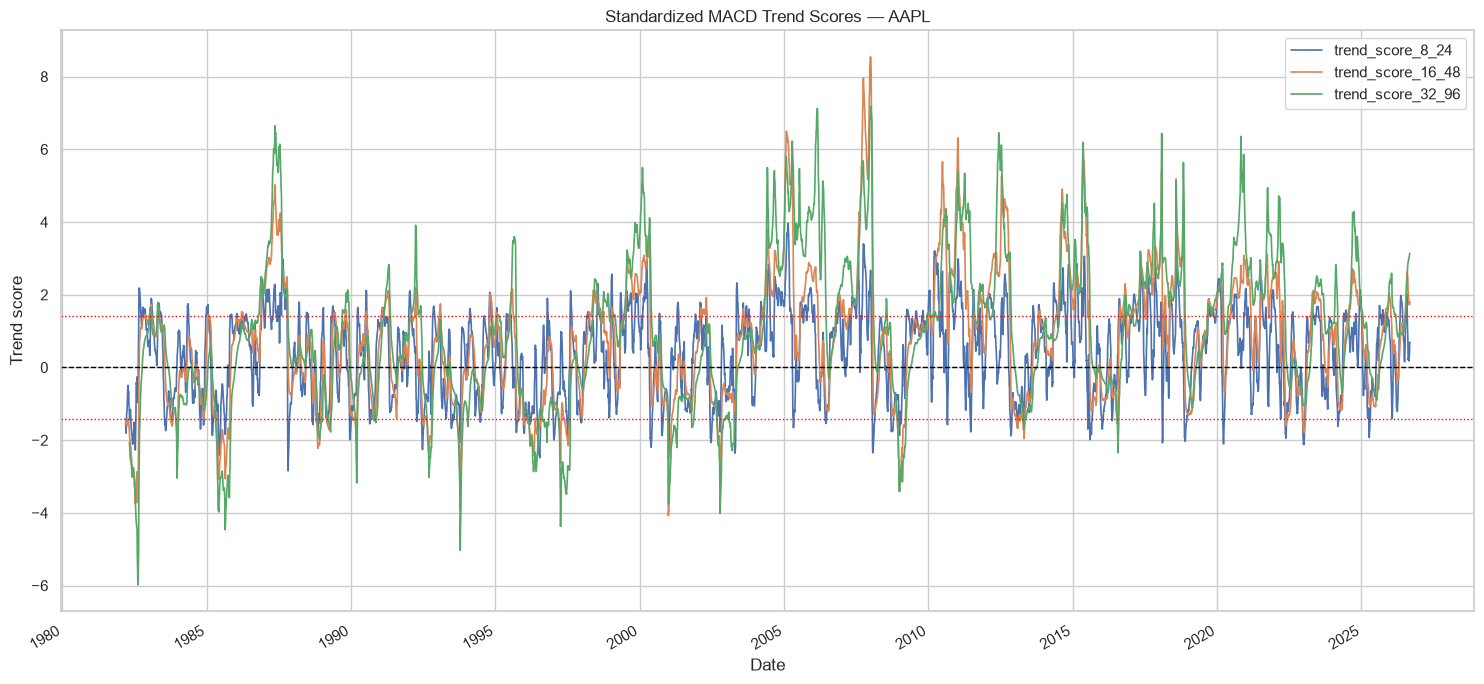

In [16]:
ticker_to_plot = "AAPL"

ticker_features = (
    feature_dataset
    .loc[
        feature_dataset["ticker"] == ticker_to_plot
    ]
    .set_index("date")
)


ax = ticker_features[TREND_COLUMNS].plot(
    figsize=(15, 7),
    linewidth=1.2,
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.axhline(
    np.sqrt(2),
    color="red",
    linestyle=":",
    linewidth=1,
    label=r"$+\sqrt{2}$",
)

ax.axhline(
    -np.sqrt(2),
    color="red",
    linestyle=":",
    linewidth=1,
    label=r"$-\sqrt{2}$",
)

ax.set_title(
    f"Standardized MACD Trend Scores — {ticker_to_plot}"
)

ax.set_xlabel("Date")
ax.set_ylabel("Trend score")

plt.tight_layout()
plt.show()

In [17]:
# ---------------------------------------------------------
# SAUVEGARDE — vers data/processed/ (chemins definis dans la cellule PATHS)
# ---------------------------------------------------------

# Securite : le dossier cible doit exister meme si la cellule
# est executee isolement.
FEATURE_FILE_CSV.parent.mkdir(parents=True, exist_ok=True)

feature_dataset.to_csv(
    FEATURE_FILE_CSV,
    index=False,
)

feature_dataset.to_parquet(
    FEATURE_FILE_PARQUET,
    index=False,
    engine="pyarrow",
)

print("Files saved:")
for path in (FEATURE_FILE_CSV, FEATURE_FILE_PARQUET):
    size_mb = path.stat().st_size / 1024**2
    print(f"  {path.relative_to(PROJECT_ROOT)}  ({size_mb:,.1f} MB)")

Files saved:
  data\processed\classical_macd_features.csv  (74.1 MB)
  data\processed\classical_macd_features.parquet  (33.6 MB)
